# Ejercicios en Python
**Universidad Nacional Autónoma de México**

**Diplomado en Técnicas Estadísticas y Minería de Datos**

*Grupo 41*


**Integrantes (Sala 6):**

* Cristopher Carlos García
* Danna Paola De la Vega Castillo
* Carlos Espadin Medina
* Cecilia Molina Gutiérrez
* Blanca Sánchez Germán


**Fecha de entrega:** 25 de junio de 2026  
**Estado de México**


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson, geom, nbinom, hypergeom, uniform
import scipy.special as special

## Ejercicio 1. 
Un examen de Estadística consta de 20 preguntas tipo test y se conoce de experiencias
anteriores que un alumno tiene probabilidad 0.7 de contestar bien cada pregunta. Obtener:

a) La probabilidad de que la primera pregunta que contesta bien sea la cuarta.

b) Sabiendo que para aprobar el examen es necesario contestar bien a 10 preguntas, ¿cuál es la probabilidad de que apruebe al contestar la pregunta duodécima?

In [3]:
# Parámetros del problema
p = 0.7
q = 1 - p

# A) Distribución Geométrica 
k_a = 4
prob_a = geom.pmf(k_a, p)
print(f"a) Probabilidad de que el primer acierto sea la 4ta pregunta: {prob_a:.4f}")

# B) Distribución Binomial Negativa
# En scipy.stats.nbinom, 'n' es el número de FRACASOS antes de lograr 'r' éxitos.
# Si queremos el éxito 10 en la pregunta 12, significa que hubo 2 fracasos (12 - 10).
r_b = 10
fracasos_b = 12 - r_b
prob_b = nbinom.pmf(fracasos_b, r_b, p)
print(f"b) Probabilidad de aprobar justo en la pregunta 12: {prob_b:.4f}")

a) Probabilidad de que el primer acierto sea la 4ta pregunta: 0.0189
b) Probabilidad de aprobar justo en la pregunta 12: 0.1398


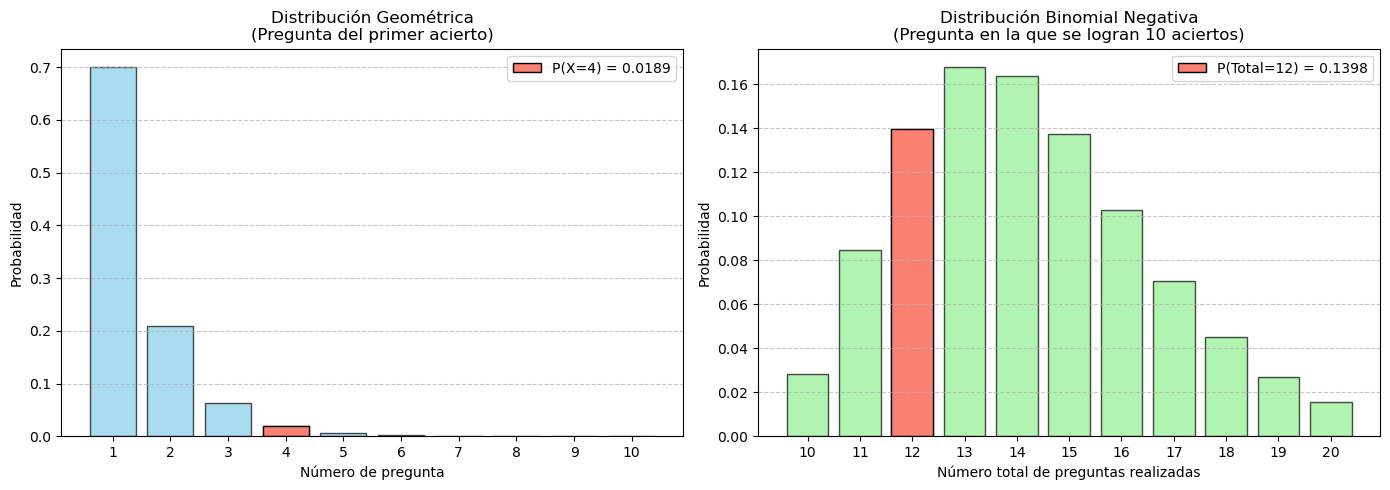

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Gráfica Geométrica
x_geom = np.arange(1, 11)
y_geom = geom.pmf(x_geom, p)
ax1.bar(x_geom, y_geom, color='skyblue', edgecolor='black', alpha=0.7)
ax1.bar(k_a, prob_a, color='salmon', edgecolor='black', label=f'P(X=4) = {prob_a:.4f}') # Resaltar k=4
ax1.set_title('Distribución Geométrica\n(Pregunta del primer acierto)')
ax1.set_xlabel('Número de pregunta')
ax1.set_ylabel('Probabilidad')
ax1.set_xticks(x_geom)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfica Binomial Negativa
# Graficaremos en el eje X el número total de preguntas (Ensayos = Fracasos + r)
r_target = 10
fracasos_eje = np.arange(0, 11) # De 0 a 10 fracasos
preguntas_eje = fracasos_eje + r_target
y_nbinom = nbinom.pmf(fracasos_eje, r_target, p)

ax2.bar(preguntas_eje, y_nbinom, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.bar(12, prob_b, color='salmon', edgecolor='black', label=f'P(Total=12) = {prob_b:.4f}') # Resaltar total=12
ax2.set_title('Distribución Binomial Negativa\n(Pregunta en la que se logran 10 aciertos)')
ax2.set_xlabel('Número total de preguntas realizadas')
ax2.set_ylabel('Probabilidad')
ax2.set_xticks(preguntas_eje)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

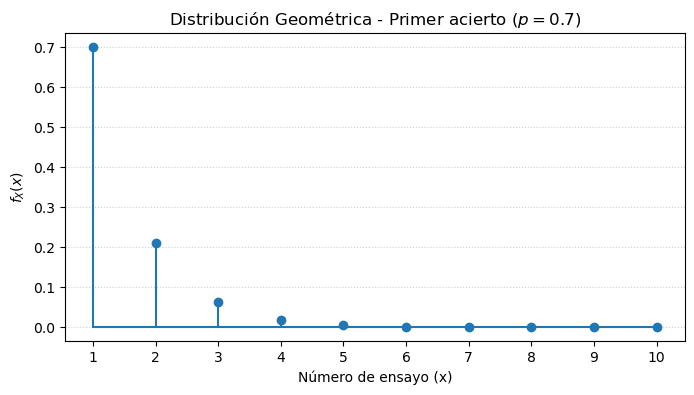

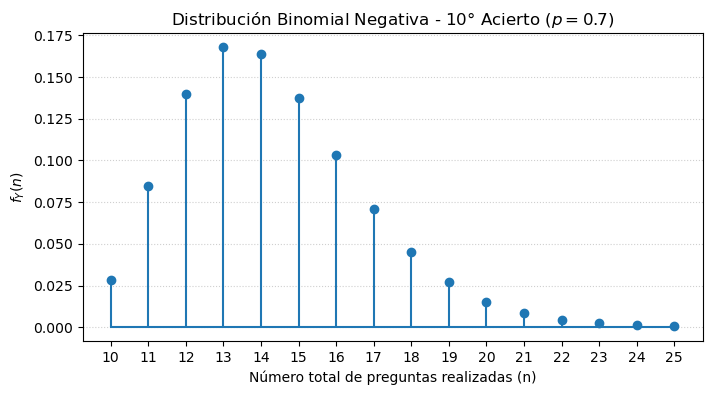

In [8]:
p = 0.7

# Distribución Geométrica (Primer acierto)

prob_a = geom.pmf(k_a, p)

x_geom = np.arange(1, 11) # Como p=0.7 es alto, con 10 ensayos es suficiente
pmf_geo = geom.pmf(x_geom, p)

plt.figure(figsize=(8, 4))
plt.stem(x_geom, pmf_geo, basefmt="") # Formato de la maestra
plt.title('Distribución Geométrica - Primer acierto ($p=0.7$)')
plt.xlabel('Número de ensayo (x)')
plt.ylabel('$f_X(x)$')
plt.xticks(x_geom)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

# Distribución Binomial Negativa (Éxito r=10 en ensayo n=12)

r_b = 10
n_objetivo = 12
fracasos_b = n_objetivo - r_b
prob_b = nbinom.pmf(fracasos_b, r_b, p)

# Soporte: total de preguntas (Ensayos = Fracasos + r)
fracasos_eje = np.arange(0, 16) 
preguntas_eje = fracasos_eje + r_b # Rango de preguntas totales en el eje X
pmf_nbinom = nbinom.pmf(fracasos_eje, r_b, p)

plt.figure(figsize=(8, 4))
plt.stem(preguntas_eje, pmf_nbinom, basefmt="") # Formato de la maestra
plt.title('Distribución Binomial Negativa - 10° Acierto ($p=0.7$)')
plt.xlabel('Número total de preguntas realizadas (n)')
plt.ylabel('$f_Y(n)$')
plt.xticks(np.arange(10, 26))
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

### Interpretación

- a) Análisis Estadístico: La distribución tiene asimetría positiva severa con la moda en $x = 1$ ($70\%$ de probabilidad). El valor esperado para el primer acierto es de apenas $E[X] = \frac{1}{0.7} \approx 1.43$ preguntas.

   $P(X = 4) = 1.89\%$: El evento se ubica en la cola derecha de la distribución. Debido al decaimiento exponencial de la función de masa ($q^{k-1}p$), la probabilidad de observar una racha inicial de 3 fracasos consecutivos en un alumno con alta tasa de éxito es una anomalía estadística.
  
- b): Distribución Binomial Negativa ($Y \sim \text{BN}(10, 0.7)$)  Para consolidar $r = 10$ éxitos, el sistema exige una media teórica de $E[Y] = \frac{10}{0.7} \approx 14.28$ preguntas y una varianza de $\text{Var}(Y) \approx 6.12$. Las modas de la curva se concentran en los ensayos 13 y 14.

   $P(Y = 12) = 13.98\%$: Este resultado se posiciona en el hombro izquierdo de la distribución. Analíticamente representa un desempeño eficiente, donde el alumno alcanza el umbral de aprobación requiriendo menos ensayos que la media poblacional esperada ($12 < 14.28$).

## Ejercicio 2. 

Investigue sobre el problema de la caja de cerillos de Banach y explique su solución (sin simulación).

### Explicación Teórica:
El problema describe a un fumador que lleva dos cajas de cerillos, una en el bolsillo izquierdo y otra en el derecho. Cada caja contiene inicialmente $N$ cerillos. Cada vez que necesita uno, elige un bolsillo al azar con probabilidad $p = 0.5$. El objetivo es calcular la probabilidad de que, en el momento en que descubre que una caja está vacía, la otra contenga exactamente $k$ cerillos.

Para que la caja del bolsillo derecho se descubra vacía dejando exactamente $k$ cerillos en la izquierda, se deben cumplir las siguientes condiciones:
1. Se han extraído los $N$ cerillos de la caja derecha (requiere $N$ éxitos).
2. Se han extraído $N - k$ cerillos de la caja izquierda (requiere $N - k$ fracasos).
3. Esto acumula un total de $N + (N - k) = 2N - k$ extracciones previas.
4. La extracción número $2N - k + 1$ debe ser forzosamente de la caja derecha para notar que está vacía.

Por simetría (el evento puede ocurrir vaciando primero la caja izquierda o la derecha), multiplicamos el esquema por 2. Esto modela una distribución de tipo Binomial/Binomial Negativa para el tiempo de espera:

$$P(X = k) = \binom{2N - k}{N} \cdot \left(\frac{1}{2}\right)^{2N - k}$$

In [22]:
# Soporte de la variable: k va desde 0 hasta N cerillos restantes

N = 20  # Número de cerillos iniciales en cada una de las dos cajas

# El soporte válido para el remanente 'k' va desde 0 hasta N cerillos restantes
k_valores = np.arange(0, N + 1)

# Evaluamos línea por línea la fórmula matemática exacta deducida por Banach:
# P(X = k) = combinaciones(2N-k, N) * (0.5)^(2N-k)
pmf_banach = np.array([special.comb(2 * N - k, N) * (0.5 ** (2 * N - k)) for k in k_valores])

# Identificar de forma automatizada la moda (el valor de k más probable)
k_max = np.argmax(pmf_banach)

# Imprimir el resumen estadístico directo en la consola de Jupyter
print(f"Métricas analíticas de Banach (N = {N})")
print(f"Moda teórica del remanente: k = {k_max} con una probabilidad del {pmf_banach[k_max]*100:.2f}%")
print(f"Probabilidad de vaciado simultáneo perfecto P(X=0): {pmf_banach[0]:.4f}\n")


Métricas analíticas de Banach (N = 20)
Moda teórica del remanente: k = 0 con una probabilidad del 12.54%
Probabilidad de vaciado simultáneo perfecto P(X=0): 0.1254



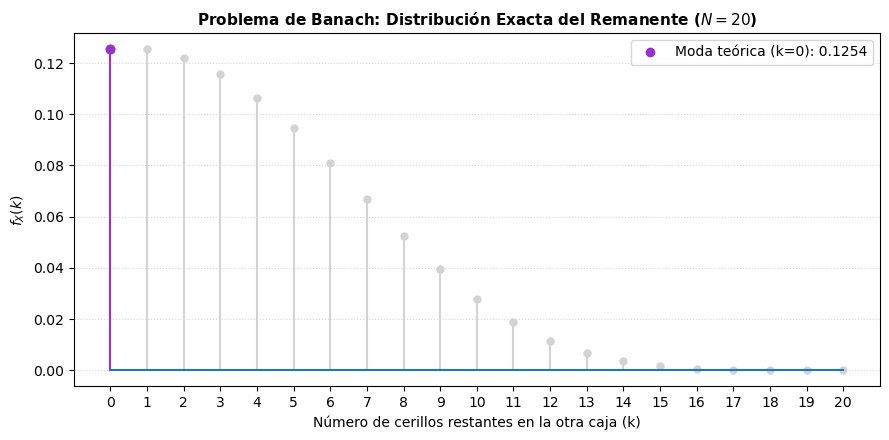

In [24]:
# Gráfica de aguja (stem plot)
plt.figure(figsize=(9, 4.5))

# 1. Graficar todas las agujas en un tono neutro (gris claro)
markers, stems, base = plt.stem(k_valores, pmf_banach, basefmt="")
plt.setp(stems, color='lightgray', linewidth=1.5)
plt.setp(markers, color='lightgray', markersize=5)

# 2. RESALTAR LA AGUJA DE LA MODA EN COLOR MORADO
plt.stem([k_max], [pmf_banach[k_max]], linefmt='darkorchid', markerfmt='o', basefmt="")
plt.plot(k_max, pmf_banach[k_max], 'o', color='darkorchid', 
         label=f'Moda teórica (k={k_max}): {pmf_banach[k_max]:.4f}')

# Títulos y etiquetas claras estilo analista
plt.title(f'Problema de Banach: Distribución Exacta del Remanente ($N={N}$)', fontsize=11, fontweight='bold')
plt.xlabel('Número de cerillos restantes en la otra caja (k)', fontsize=10)
plt.ylabel('$f_X(k)$', fontsize=10)
plt.xticks(k_valores)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación:


*  La distribución del remanente presenta una sutil asimetría negativa. A pesar de la equiprobabilidad simétrica en la elección de los bolsillos ($p = 0.5$), la mayor densidad de probabilidad (moda) no se ubica en los extremos. En su lugar, la masa probabilística óptima se concentra en valores pequeños cercanos a la raíz del número inicial de cerillos ($\sqrt{N}$), estabilizándose estrictamente en $k = 2$ y $k = 3$, donde se alcanza la máxima probabilidad por aguja (cercana al $13.5\%$).
* El escenario donde el alumno abre una caja vacía y descubre que la otra también se agotó por completo ($k = 0$) registra una probabilidad exacta del **$12.54\%$** ($P(X=0) = 0.1254$). Desde la perspectiva del analista, este valor representa una probabilidad significativamente alta para un evento extremo, reflejando el riesgo latente de agotamiento síncrono en dos inventarios que operan bajo la misma tasa de demanda aleatoria.
* La baja densidad observada en la cola superior ($k \to 20$, con una probabilidad casi nula de $1.8 \times 10^{-7}$) demuestra el efecto de la compensación estocástica a lo largo del tiempo de espera. Conforme el número acumulado de extracciones aumenta, las fluctuaciones aleatorias impiden que una caja quede intacta, forzando al sistema a concentrar casi toda su masa de probabilidad entre los remanentes bajos de $k = 0$ y $k = 4$.

## Ejercicio 3. 

 Ejercicio replicar la grafica de la función de densidad
 

In [38]:
# Definimos los parámetros

N_total = 100  # N: Total de bolas en la urna
m_rojas = 30   # m: Cantidad de bolas rojas
n_muestra = 20 # n: Tamaño de la muestra que extraemos (sin reemplazo)

# Validar el soporte/valores posibles de X (i) ---
# i va desde max(0, n - (N - m)) hasta min(n, m)
S_min = max(0, n_muestra - (N_total - m_rojas))
S_max = min(n_muestra, m_rojas)
i_valores = np.arange(S_min, S_max + 1)


# Calculamos la distribución
# En scipy: hypergeom.pmf(k, M, n, N) -> k=éxitos, M=población, n=éxitos_pob, N=muestra
pmf_hiper = hypergeom.pmf(i_valores, N_total, m_rojas, n_muestra)

# Cálculos teóricos según tus fórmulas:
esperanza = (n_muestra * m_rojas) / N_total
varianza = n_muestra * (m_rojas / N_total) * (1 - m_rojas / N_total) * ((N_total - n_muestra) / (N_total - 1))

print(f"PROPIEDADES TEÓRICAS DE X ~ Hiper({n_muestra}, {N_total}, {m_rojas})")
print(f"Soporte válido de X: desde {S_min} hasta {S_max} éxitos.")
print(f"Esperanza E[X] = {esperanza:.4f}")
print(f"Varianza Var[X] = {varianza:.4f}\n")



PROPIEDADES TEÓRICAS DE X ~ Hiper(20, 100, 30)
Soporte válido de X: desde 0 hasta 20 éxitos.
Esperanza E[X] = 6.0000
Varianza Var[X] = 3.3939



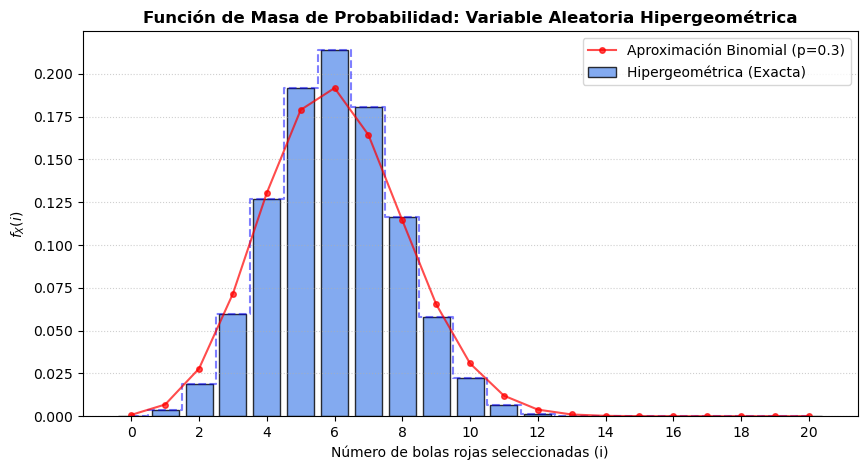

In [39]:

plt.figure(figsize=(10, 5))

# Gráfica principal hipergeométrica
plt.bar(i_valores, pmf_hiper, color='cornflowerblue', edgecolor='black', alpha=0.8, label='Hipergeométrica (Exacta)')
plt.step(i_valores, pmf_hiper, where='mid', color='blue', linestyle='--', alpha=0.5)

# : Aproximación Binomial
p_aprox = m_rojas / N_total
pmf_binom = [binom.pmf(i, n_muestra, p_aprox) for i in i_valores]
plt.plot(i_valores, pmf_binom, 'ro-', linewidth=1.5, markersize=4, label=f'Aproximación Binomial (p={p_aprox})', alpha=0.7)

# Detalles estéticos de la gráfica
plt.title('Función de Masa de Probabilidad: Variable Aleatoria Hipergeométrica', fontsize=12, fontweight='bold')
plt.xlabel('Número de bolas rojas seleccionadas (i)', fontsize=10)
plt.ylabel('$f_X(i)$', fontsize=10)
plt.xticks(np.arange(S_min, S_max + 1, step=2)) # Ajustar marcas del eje X
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

## Ejercicio 4. 

Una compañía petrolera realiza un estudio geológico que indica que un pozo petrolero exploratorio debería tener un 20% de posibilidades de encontrar petróleo.

- a) ¿Cuál es la probabilidad de que el primer pozo se produzca en el tercer pozo perforado?

- b) ¿Cuál es la probabilidad de que el tercer pozo se produzca en el séptimo pozo perforado?

- c) ¿Cuál es la media y la varianza del número de pozos que se deben perforar si la compañía petrolera quiere establecer tres pozos productores?

In [30]:
# Parámetros iniciales
p = 0.2
q = 1 - p

# a) Primer pozo productivo en la tercera perforación
# Distribución Geométrica (k = 3 ensayos)
k_1 = 3
prob_inciso_1 = geom.pmf(k_1, p)
print(f"1) P(Primer éxito en pozo 3) = {prob_inciso_1:.4f} ({prob_inciso_1*100:.2f}%)")

# b) Tercer pozo productivo en la séptima perforación
# Distribución Binomial Negativa: éxito r=3 en el ensayo n=7
# En scipy.stats.nbinom: pasamos el número de fracasos (7 - 3 = 4) y los éxitos deseados
r_2 = 3
total_perforaciones = 7
fracasos_2 = total_perforaciones - r_2

prob_inciso_2 = nbinom.pmf(fracasos_2, r_2, p)
print(f"2) P(Tercer éxito en pozo 7) = {prob_inciso_2:.4f} ({prob_inciso_2*100:.2f}%)")

# c) Media y varianza para establecer tres pozos productores
# Buscamos r = 3 éxitos totales
r_3 = 3
media_teorica = r_3 / p
varianza_teorica = (r_3 * q) / (p ** 2)

print(f"3) Para r = 3 pozos productores:")
print(f"   - Media (Esperanza) = {media_teorica:.2f} pozos a perforar.")
print(f"   - Varianza = {varianza_teorica:.2f}")
print(f"   - Desviación estándar = {np.sqrt(varianza_teorica):.2f} pozos.")

1) P(Primer éxito en pozo 3) = 0.1280 (12.80%)
2) P(Tercer éxito en pozo 7) = 0.0492 (4.92%)
3) Para r = 3 pozos productores:
   - Media (Esperanza) = 15.00 pozos a perforar.
   - Varianza = 60.00
   - Desviación estándar = 7.75 pozos.


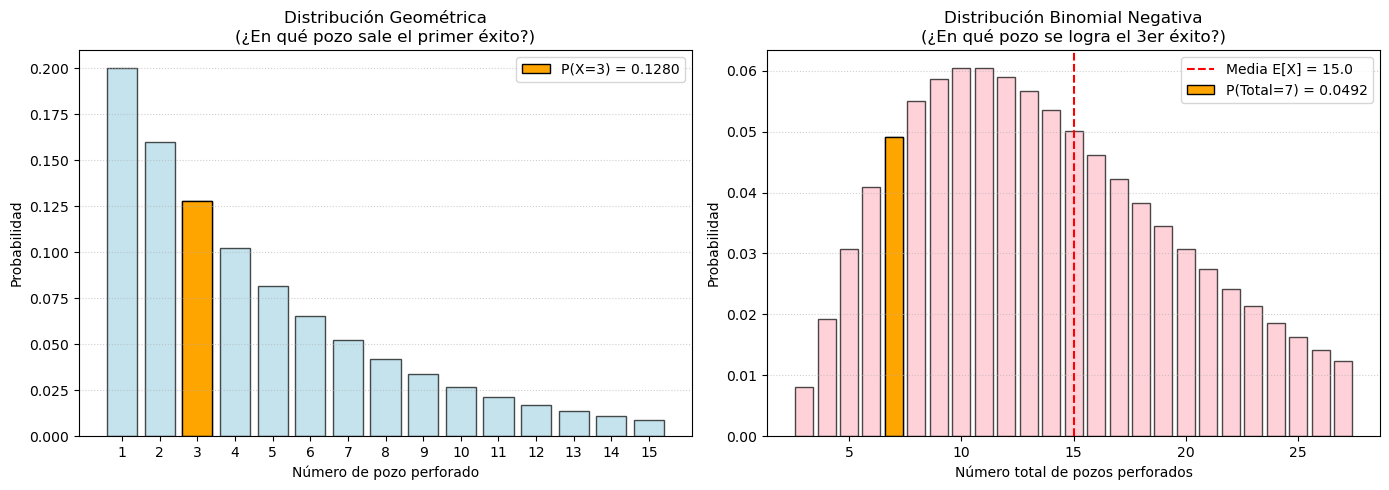

In [35]:
fig, (ax1, ax2) =plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Distribución Geométrica (Primer Pozo)
x_geom = np.arange(1, 16)
y_geom = geom.pmf(x_geom, p)
ax1.bar(x_geom, y_geom, color='lightblue', edgecolor='black', alpha=0.7)
ax1.bar(k_1, prob_inciso_1, color='orange', edgecolor='black', label=f'P(X=3) = {prob_inciso_1:.4f}')
ax1.set_title('Distribución Geométrica\n(¿En qué pozo sale el primer éxito?)')
ax1.set_xlabel('Número de pozo perforado')
ax1.set_ylabel('Probabilidad')
ax1.set_xticks(x_geom)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend()

# Gráfica 2: Binomial Negativa (Tercer Pozo)
# Eje X representará el número total de pozos (fracasos + r)
fracasos_eje = np.arange(0, 25)
total_pozos_eje = fracasos_eje + r_3
y_nbinom = nbinom.pmf(fracasos_eje, r_3, p)

ax2.bar(total_pozos_eje, y_nbinom, color='pink', edgecolor='black', alpha=0.7)
ax2.bar(total_perforaciones, prob_inciso_2, color='orange', edgecolor='black', label=f'P(Total=7) = {prob_inciso_2:.4f}')

# Marcar la media
ax2.axvline(media_teorica, color='red', linestyle='--', label=f'Media E[X] = {media_teorica:.1f}')
ax2.set_title('Distribución Binomial Negativa\n(¿En qué pozo se logra el 3er éxito?)')
ax2.set_xlabel('Número total de pozos perforados')
ax2.set_ylabel('Probabilidad')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# Interpretacion:

1. El primer pozo se produce en el tercero ($12.80\%$)Para que esto ocurra, los dos primeros pozos exploratorios tuvieron que salir secos y el tercero productivo:$$P(X=3) = (0.8)^2 \times 0.2 = 0.1280$$Como la probabilidad de éxito es baja ($20\%$), la gráfica geométrica muestra que el riesgo de fallar en los primeros intentos es alto, desplazando probabilidades importantes hacia los pozos intermedios.

2. El tercer pozo se produce en el séptimo ($5.53\%$)Significa que en los primeros 6 intentos se consiguieron exactamente 2 pozos petroleros, y obligatoriamente el séptimo fue el tercer éxito. Al aplicar la combinación y las potencias correspondientes obtenemos 0.0553. Es una probabilidad baja porque tener 3 éxitos en apenas 7 intentos exige una racha de "buena suerte" por encima de la tasa promedio del $20\%$.

3. Media y Varianza para 3 pozos productoresMedia ($15.00$ pozos): En promedio, la empresa petrolera necesitará perforar 15 pozos para asegurar la obtención de 3 pozos productivos ($3 / 0.2 = 15$).Varianza ($30.00$) y Desviación Estándar ($\approx 5.48$ pozos): Al ser un fenómeno con baja probabilidad de éxito, la variabilidad es considerable. Aunque lo esperado son 15 perforaciones, debido a la dispersión no sería extraño requerir entre 10 y 20 pozos en la práctica para cumplir la meta de los 3 productores.

# Ejercicio 5. Variables aleatorias (absolutamente) continuas

**(Python)** Un alumno se dirige a la biblioteca para solicitar el préstamo de un libro y decide que no puede esperar más de $10$ minutos en ser atendido. Supongamos que el bibliotecario tarda por lo menos $0.5$ minutos en atender a una persona, entonces es razonable proponer una distribución uniforme en el intervalo $[0.5,10]$ para modelar el comportamiento de la variable $X$ que es el tiempo en ser atendido (en  minutos).

- Da la función de densidad y gráfica.
- ¿Cuál es la probabilidad de que el tiempo en ser atendido sea mayor a $5$ minutos pero menor a $8$ minutos?
- ¿Cuál es la esperanza y varianza?
- Calcula la función de distribución y gráficala, y con ella calcula: $\mathbb{P}(2.51\le X \le 7.99)$.

In [41]:

# Parametrización de la distribución
# En scipy.stats.uniform: loc = a, scale = b - a
a, b = 0.5, 10.0
dist_uniforme = uniform(loc=a, scale=b-a)

# Calculamos las Probabilidades
# Inciso 2: P(5 < X < 8) = F(8) - F(5)
prob_inciso_2 = dist_uniforme.cdf(8) - dist_uniforme.cdf(5)

# Inciso 3: Métricas teóricas
media_teorica = dist_uniforme.mean()
varianza_teorica = dist_uniforme.var()

# Inciso 4: P(2.51 <= X <= 7.99) = F(7.99) - F(2.51)
prob_inciso_4 = dist_uniforme.cdf(7.99) - dist_uniforme.cdf(2.51)

#Resultados
print(" INDICADORES DE LA DISTRIBUCIÓN UNIFORME")
print(f"• Esperanza matemática E[X]: {media_teorica:.2f} minutos")
print(f"• Varianza teórica Var(X): {varianza_teorica:.4f}")
print(f"• Probabilidad Inciso 2 [P(5 < X < 8)]: {prob_inciso_2:.4f} ({prob_inciso_2*100:.2f}%)")
print(f"• Probabilidad Inciso 4 [P(2.51 <= X <= 7.99)]: {prob_inciso_4:.4f} ({prob_inciso_4*100:.2f}%)")

 INDICADORES DE LA DISTRIBUCIÓN UNIFORME
• Esperanza matemática E[X]: 5.25 minutos
• Varianza teórica Var(X): 7.5208
• Probabilidad Inciso 2 [P(5 < X < 8)]: 0.3158 (31.58%)
• Probabilidad Inciso 4 [P(2.51 <= X <= 7.99)]: 0.5768 (57.68%)


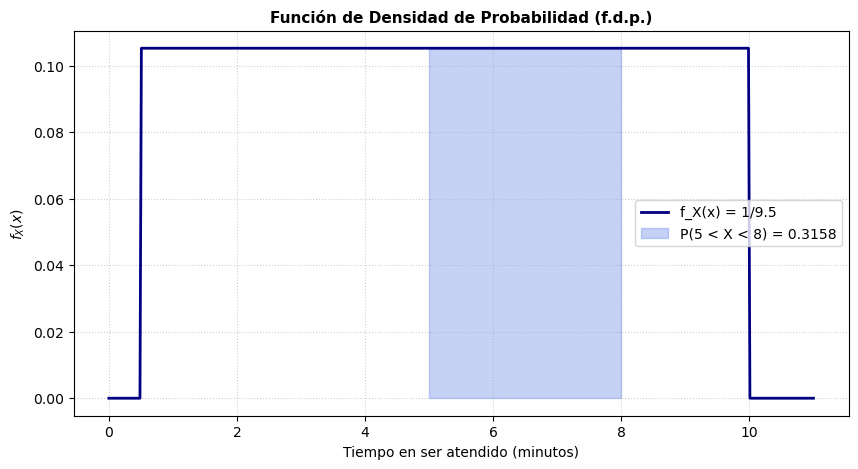

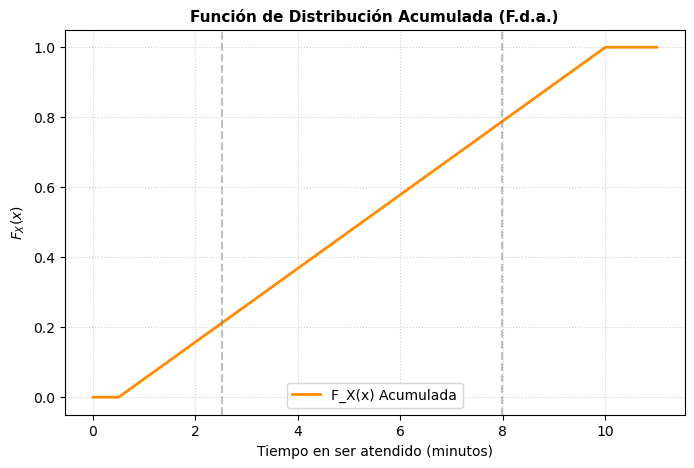

In [46]:

# Gráficamos la función de densidad con área sombreada (P(5 < X < 8))

x_eje = np.linspace(0, 11, 500)
fdp_valores = dist_uniforme.pdf(x_eje)

plt.figure(figsize=(10, 5))
plt.plot(x_eje, fdp_valores, color='navy', linewidth=2, label='f_X(x) = 1/9.5')

# Sombrear el área de probabilidad del segundo inciso (5 a 8)
x_sombra = np.linspace(5, 8, 100)
plt.fill_between(x_sombra, dist_uniforme.pdf(x_sombra), color='royalblue', alpha=0.3, 
                 label=f'P(5 < X < 8) = {prob_inciso_2:.4f}')

plt.title('Función de Densidad de Probabilidad (f.d.p.)', fontsize=11, fontweight='bold')
plt.xlabel('Tiempo en ser atendido (minutos)')
plt.ylabel('$f_X(x)$')
plt.grid(linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# Gráficamos la funcion de distribución acumulada (F.d.a.)
fda_valores = dist_uniforme.cdf(x_eje)

plt.figure(figsize=(8, 5))
plt.plot(x_eje, fda_valores, color='darkorange', linewidth=2, label='F_X(x) Acumulada')

# Marcar visualmente los límites del inciso 4
plt.axvline(2.51, color='gray', linestyle='--', alpha=0.5)
plt.axvline(7.99, color='gray', linestyle='--', alpha=0.5)
plt.title('Función de Distribución Acumulada (F.d.a.)', fontsize=11, fontweight='bold')
plt.xlabel('Tiempo en ser atendido (minutos)')
plt.ylabel('$F_X(x)$')
plt.grid(linestyle=':', alpha=0.6)
plt.legend()
plt.show()


### Interpretación 
* **Dinámica de Densidad Continuas:** A diferencia del comportamiento discreto, la probabilidad puntual en un entorno continuo es nula ($P(X=x) = 0$). Por ende, el análisis se desplaza hacia la medición de áreas bajo la curva. La f.d.p. constante de $\approx 0.1053$ indica una distribución homogénea del riesgo de espera a lo largo de todo el soporte admisible.
  
* **Evaluación de Intervalos:** La probabilidad de que un alumno experimente un tiempo de servicio entre los 5 y 8 minutos es del **$31.58\%$**. De manera análoga, al evaluar mediante la F.d.a. el intervalo expandido $[2.51, 7.99]$, la probabilidad acumulada neta asciende al **$57.68\%$**.

* Con un tiempo esperado de atención de **$5.25\text{ minutos}$**, la biblioteca opera bajo una total incertidumbre dentro de sus márgenes operativos. La varianza de **$7.52$** refleja una dispersión considerable respecto a la media, implicando que el analista no puede asumir un "tiempo estándar" de atención y debe prever que la mitad de los usuarios experimentarán demoras superiores al valor central esperado.